## EASY VISA EXPLORATORY DATA ANALYSIS

Project Overview
In this project, you will apply your data science and machine learning skills

to develop a predictive model for Easy Visa Dataset. This project will involve

data cleaning, exploratory data analysis (EDA), data preprocessing, model

training,hyperparameter tuning and evaluati

In [41]:
# importing necessary libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Phase 1

Task 1 & 2: Data Ingestion

In [42]:
def data_loading(url):
    """This function ingest and loads dataset"""
    df = pd.read_csv(url)
    print("Data is loading...")
    return df.head()

In [43]:
data_loading("https://raw.githubusercontent.com/ek-chris/Practice_datasets/refs/heads/main/EasyVisa%20(1).csv")

Data is loading...


,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [44]:
df = pd.read_csv(url)
df.columns

Index(['case_id', 'continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'no_of_employees', 'yr_of_estab',
       'region_of_employment', 'prevailing_wage', 'unit_of_wage',
       'full_time_position', 'case_status'],
      dtype='object')

In [45]:
df.shape

(25480, 12)

In [46]:
# Knowing data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


Task 1.3 & 1.4- Inspect the dataset for missing values and handle them
appropriately

In [47]:
df.isna().sum()

case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64

Report: From the above, the dataset has no missing values

In [48]:
# Dropping case_id

df = df.drop(columns=["case_id"])

## PHASE 2: Explorator Data Analysis

Task 2.1: Conduct exploratory data analysis to understand the distribution
of features and the target variable 

Numeric Category

In [49]:
# Select numerical columns
num_columns = df.select_dtypes(include="number").columns
num_columns

Index(['no_of_employees', 'yr_of_estab', 'prevailing_wage'], dtype='object')

In [50]:
# Let's check the Statistical analyis of numerical columns
df.describe(include="number").T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.0,5667.043210,22877.928848,-26.0000,1022.00,2109.00,3504.0000,602069.00
yr_of_estab,25480.0,1979.409929,42.366929,1800.0000,1976.00,1997.00,2005.0000,2016.00
prevailing_wage,25480.0,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27


|Feature  | Distribution | Outlier|Spread                |
|----------|--------------|--------|----------------|
|no_of_employees| widely distributed| Heavily present| Widely spread|
|yr_of_establish| normally distributed| Absent| moderately spread|
|prevailing_wage | roughly distributed| Heavily present| widely spread| 

In [51]:
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


Categorical Columns

In [52]:
cat_columns = df.select_dtypes(include="object").columns
cat_columns

Index(['continent', 'education_of_employee', 'has_job_experience',
       'requires_job_training', 'region_of_employment', 'unit_of_wage',
       'full_time_position', 'case_status'],
      dtype='object')

In [72]:
# Relationships of categporical column

def categorical_eda(df, column):
    """Performs EDA on categorical features."""
    print(f"\nFeature: {column}")
    print("\n+" * 30)

    # To know prequencey
    freq = pd.DataFrame(df[column].value_counts())
    # pd_converter = pd.DataFrame([freq])

    print(freq)

In [69]:
for cat in cat_columns:
    categorical_eda(df, cat)

# categorical_eda(df, "continent")

Feature: continent
++++++++++++++++++++++++++++++
               count
continent           
Asia           16861
Europe          3732
North America   3292
South America    852
Africa           551
Oceania          192
Feature: education_of_employee
++++++++++++++++++++++++++++++
                       count
education_of_employee       
Bachelor's             10234
Master's                9634
High School             3420
Doctorate               2192
Feature: has_job_experience
++++++++++++++++++++++++++++++
                    count
has_job_experience       
Y                   14802
N                   10678
Feature: requires_job_training
++++++++++++++++++++++++++++++
                       count
requires_job_training       
N                      22525
Y                       2955
Feature: region_of_employment
++++++++++++++++++++++++++++++
                      count
region_of_employment       
Northeast              7195
South                  7017
West                   6586
Midw

Task 2.2: Visualize the relationships between features and the target
variable using scatter plots, histograms, and box plots.

Visusalizing Relationship between numerical columns

In [73]:
num_columns

Index(['no_of_employees', 'yr_of_estab', 'prevailing_wage'], dtype='object')

In [87]:
def univariate_num_vis(df, column):
    """This shows the visual representation of numerical columns"""
    plt.figure(figsize=(12,4))

    # plotting histogram
    plt.subplot(1,2,1)
    sns.histplot(x=column, data=df, bins=30, kde=True)
    plt.title(f"Histogram of {column}")

    # plotting boxplot
    plt.subplot(1,2,2)
    sns.boxplot(data=df, x=column)
    plt.title(F"Boxplot of {column}")


    plt.tight_layout
    plt.show()

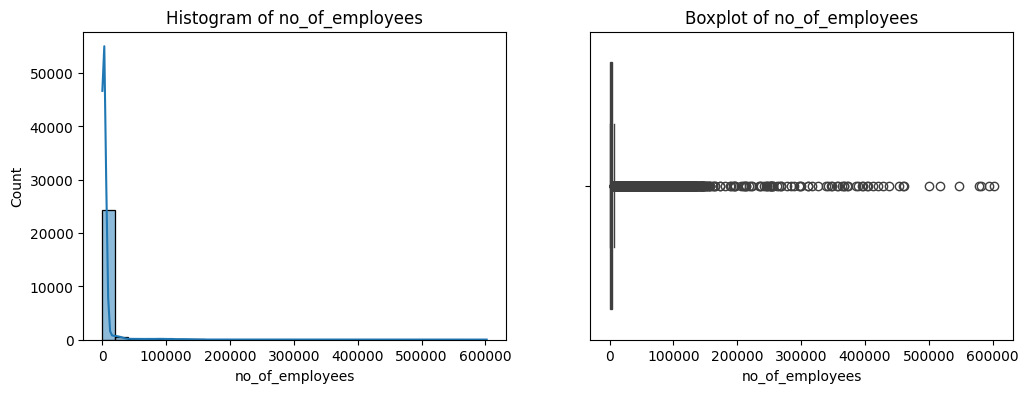

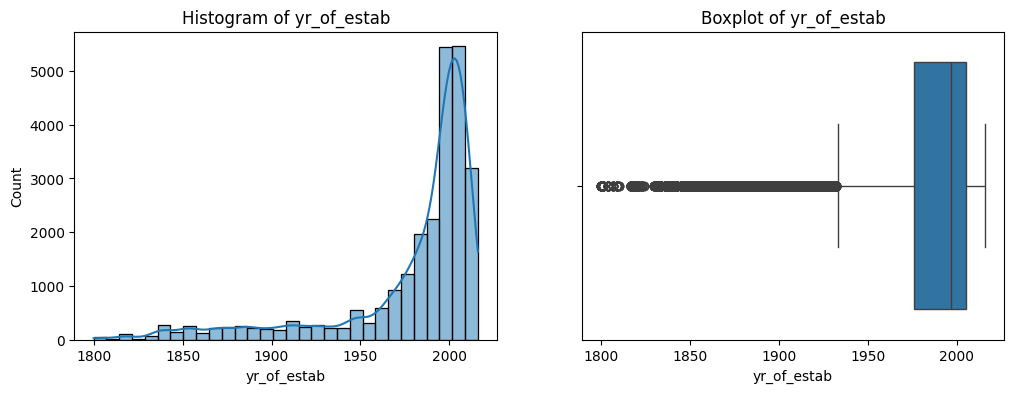

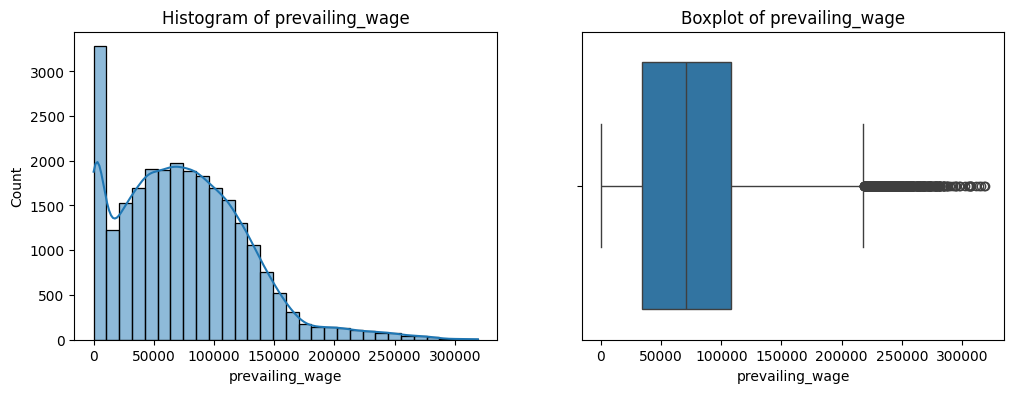

In [84]:
for col in num_columns:
    univariate_num_vis(df, col)

Report:
 
1- EMployee = rightly skewed and a lot of outliers

2- yr_of_establishmen - lefly skewed with outliers

3- Prevailing_wage - rightly skewed with outliers


Visusalizing Relationship between categorical columns

In [86]:
df.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


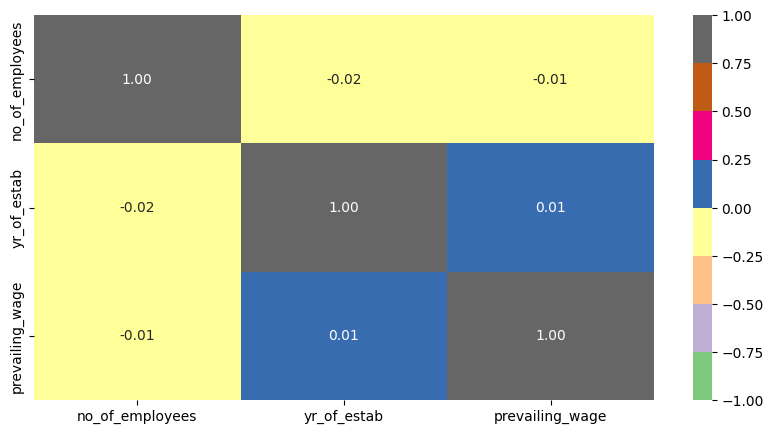

In [95]:
cols_list = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(10, 5))
sns.heatmap(
    df[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Accent"
)
plt.show()

In [97]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = df[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=df[df[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=df[df[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=df, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=df,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

C:\Users\ncc\AppData\Local\Temp\ipykernel_2532\249615426.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")
C:\Users\ncc\AppData\Local\Temp\ipykernel_2532\249615426.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


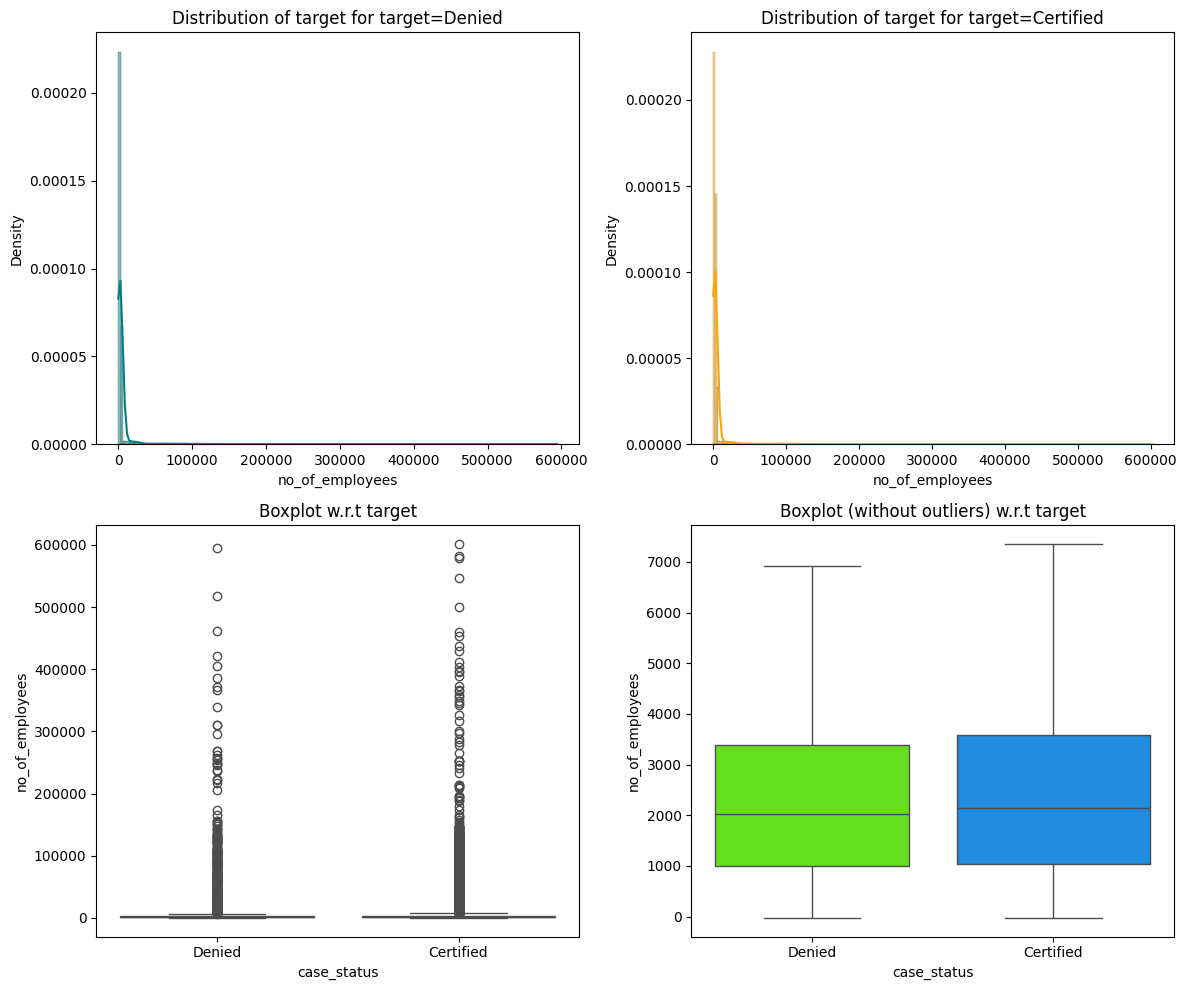

C:\Users\ncc\AppData\Local\Temp\ipykernel_2532\249615426.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")
C:\Users\ncc\AppData\Local\Temp\ipykernel_2532\249615426.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


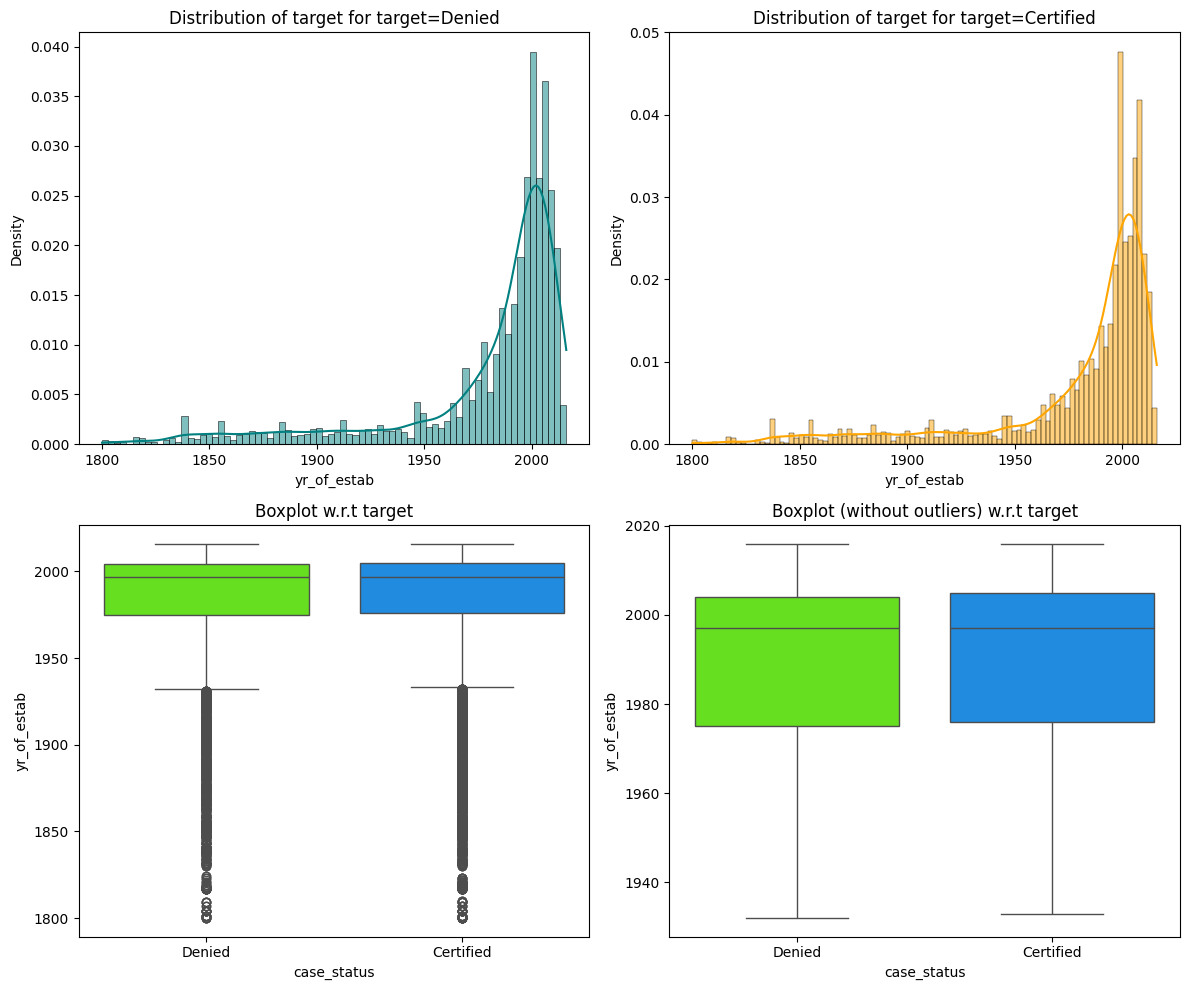

C:\Users\ncc\AppData\Local\Temp\ipykernel_2532\249615426.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")
C:\Users\ncc\AppData\Local\Temp\ipykernel_2532\249615426.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


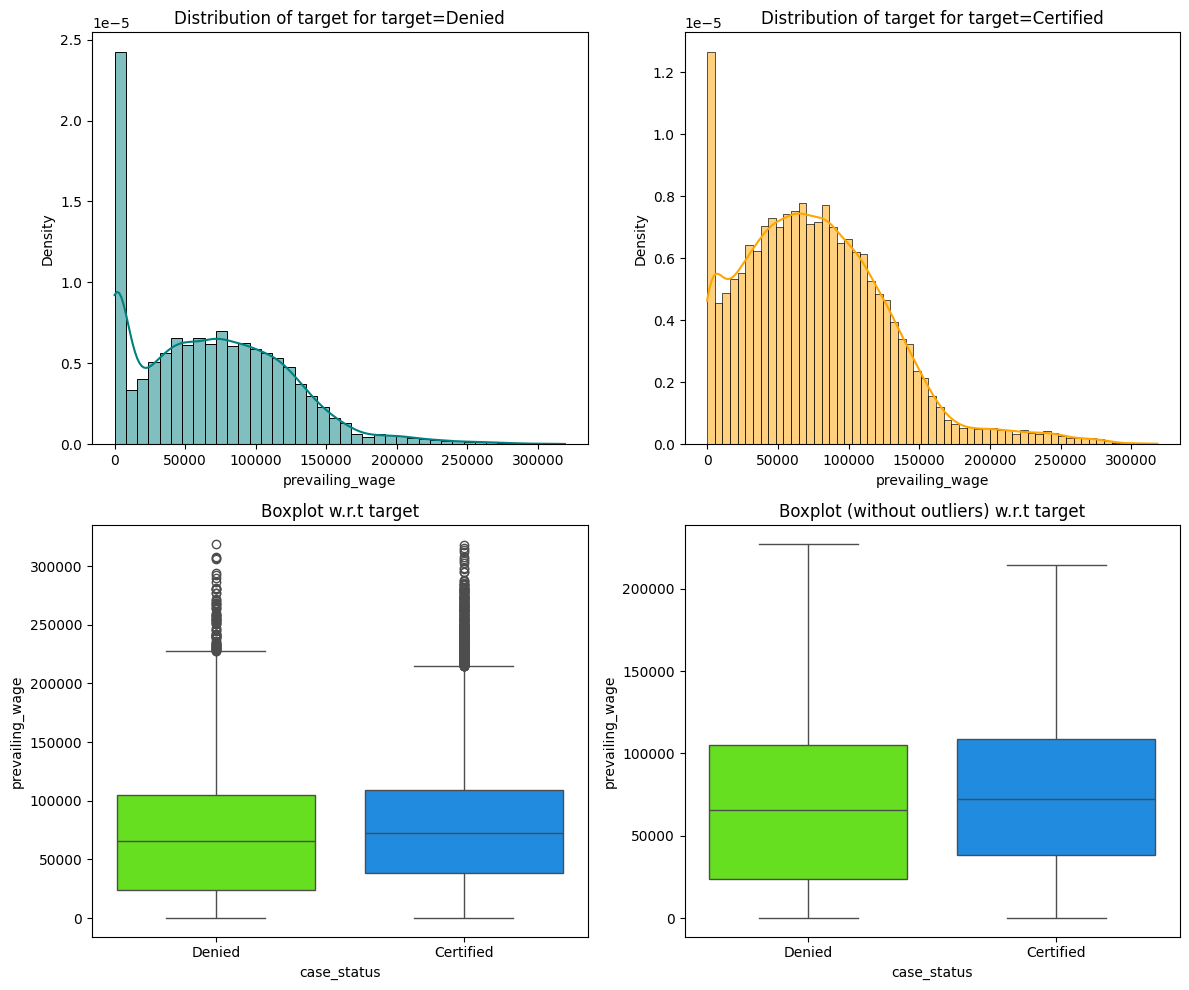

In [98]:

for col in num_columns:
    distribution_plot_wrt_target(df, col, "case_status")

For Categorical column

In [99]:
def stacked_barplot(df, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = df[predictor].nunique()
    sorter = df[target].value_counts().index[-1]
    tab1 = pd.crosstab(df[predictor], df[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(df[predictor], df[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

case_status    Certified  Denied    All
continent                              
All                17018    8462  25480
Asia               11012    5849  16861
North America       2037    1255   3292
Europe              2957     775   3732
South America        493     359    852
Africa               397     154    551
Oceania              122      70    192
------------------------------------------------------------------------------------------------------------------------


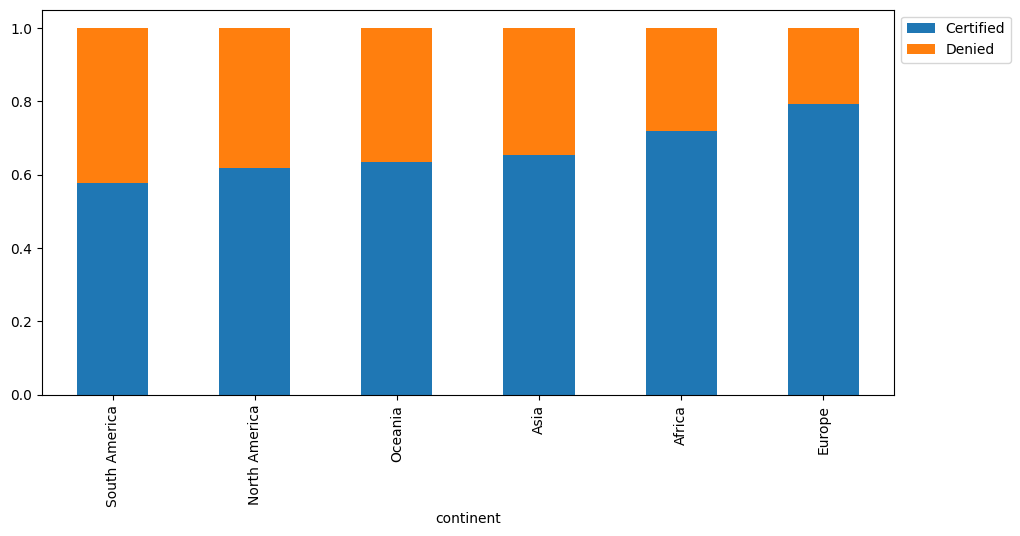

case_status            Certified  Denied    All
education_of_employee                          
All                        17018    8462  25480
Bachelor's                  6367    3867  10234
High School                 1164    2256   3420
Master's                    7575    2059   9634
Doctorate                   1912     280   2192
------------------------------------------------------------------------------------------------------------------------


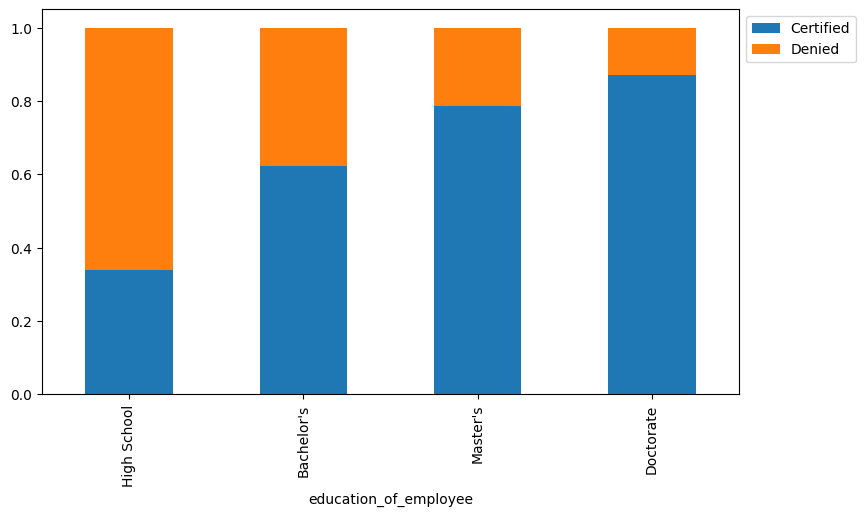

case_status         Certified  Denied    All
has_job_experience                          
All                     17018    8462  25480
N                        5994    4684  10678
Y                       11024    3778  14802
------------------------------------------------------------------------------------------------------------------------


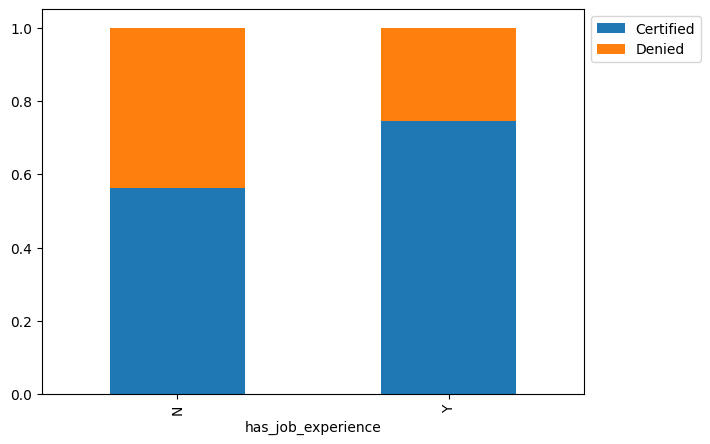

case_status            Certified  Denied    All
requires_job_training                          
All                        17018    8462  25480
N                          15012    7513  22525
Y                           2006     949   2955
------------------------------------------------------------------------------------------------------------------------


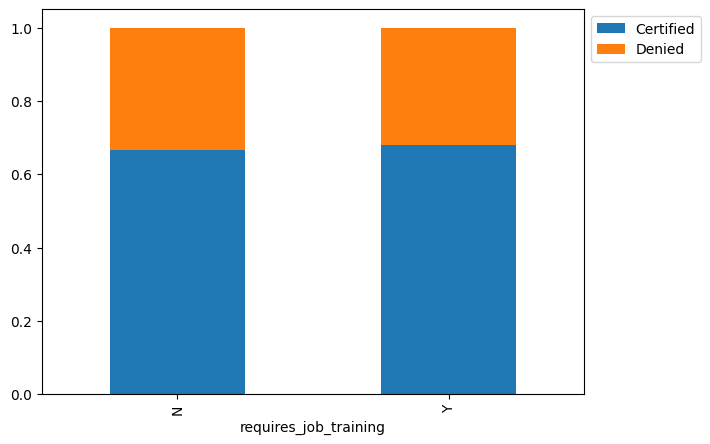

case_status           Certified  Denied    All
region_of_employment                          
All                       17018    8462  25480
Northeast                  4526    2669   7195
West                       4100    2486   6586
South                      4913    2104   7017
Midwest                    3253    1054   4307
Island                      226     149    375
------------------------------------------------------------------------------------------------------------------------


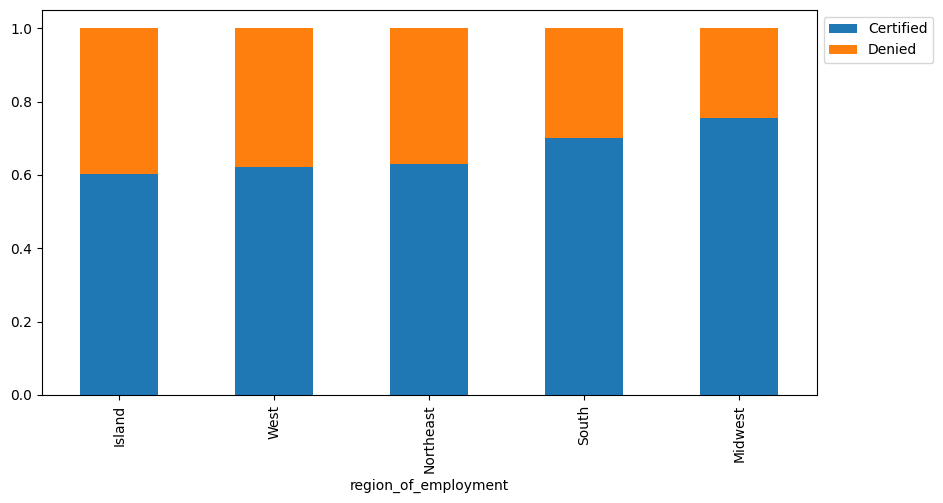

case_status   Certified  Denied    All
unit_of_wage                          
All               17018    8462  25480
Year              16047    6915  22962
Hour                747    1410   2157
Week                169     103    272
Month                55      34     89
------------------------------------------------------------------------------------------------------------------------


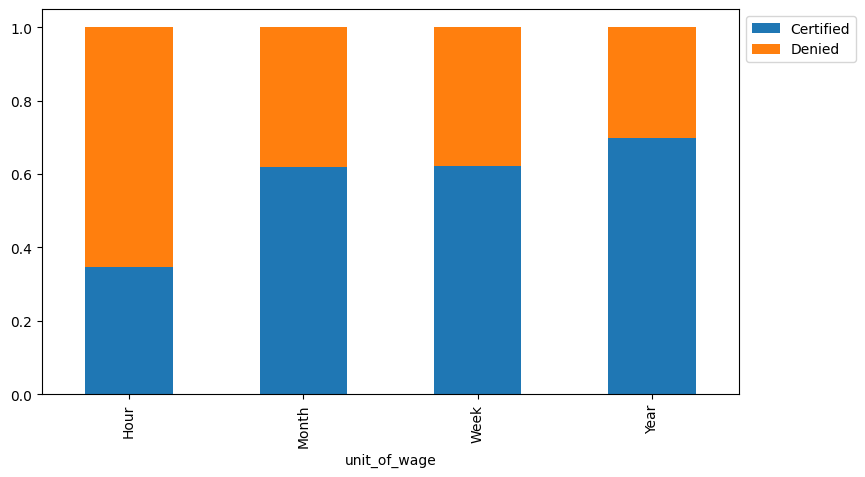

case_status         Certified  Denied    All
full_time_position                          
All                     17018    8462  25480
Y                       15163    7610  22773
N                        1855     852   2707
------------------------------------------------------------------------------------------------------------------------


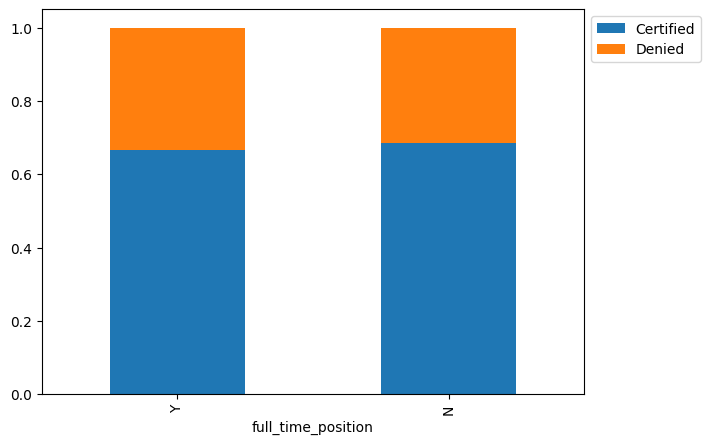

case_status  Certified  Denied    All
case_status                          
Denied               0    8462   8462
All              17018    8462  25480
Certified        17018       0  17018
------------------------------------------------------------------------------------------------------------------------


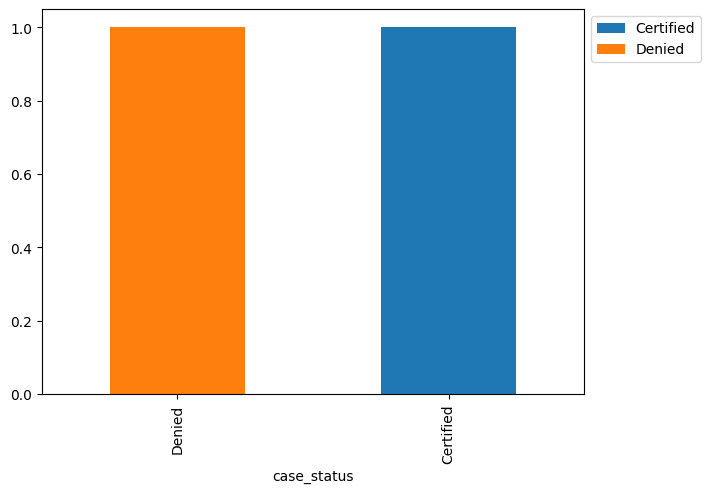

In [102]:
for col in cat_columns:
    stacked_barplot(df, col, target="case_status")

In [104]:
df.to_csv("easy_visa_eda.csv")